In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

category_columns = ["background_app_usage_level","signal_strength_avg"]

data = pd.read_excel("clean_data.xlsx")
my_columns = category_columns

print("Data Types")
print(data[my_columns].dtypes)

Data Types
background_app_usage_level    object
signal_strength_avg           object
dtype: object


Value Counts

background_app_usage_level:
background_app_usage_level
Low       1707
Medium    1684
High      1609
Name: count, dtype: int64

signal_strength_avg:
signal_strength_avg
Good        3025
Moderate    1509
Poor         466
Name: count, dtype: int64


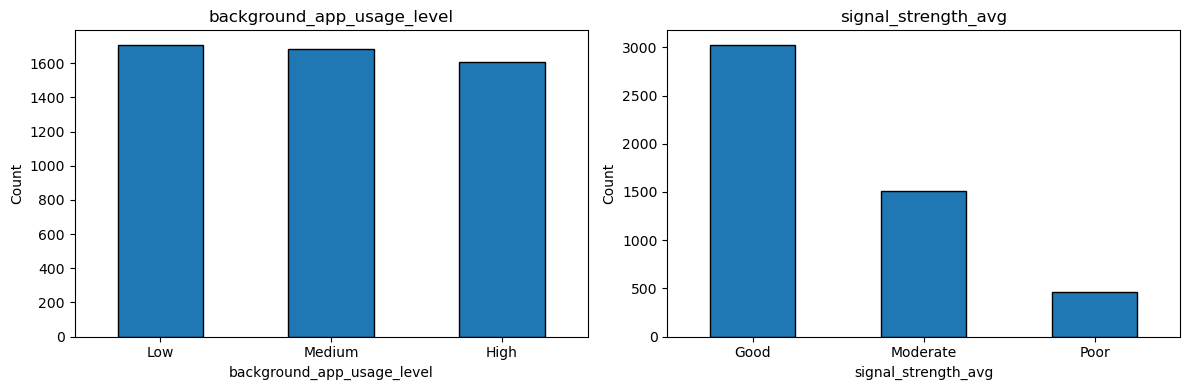

In [34]:
if category_columns:
    print("Value Counts")
    for col in category_columns:
        print(f"\n{col}:")
        print(data[col].value_counts())

if category_columns:
    n = len(category_columns)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    axes = [axes] if n == 1 else axes
 
    for ax, col in zip(axes, category_columns):
        data[col].value_counts().plot(kind="bar", ax=ax, edgecolor="black")
        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=0)
 
    plt.tight_layout()
    plt.savefig("segment_bar_charts.png", dpi=150)
    plt.show()


background_app_usage_level — mean battery health by group:
background_app_usage_level
High      63.096147
Low       62.434856
Medium    62.280285
Name: current_battery_health_percent, dtype: float64


<Figure size 600x400 with 0 Axes>

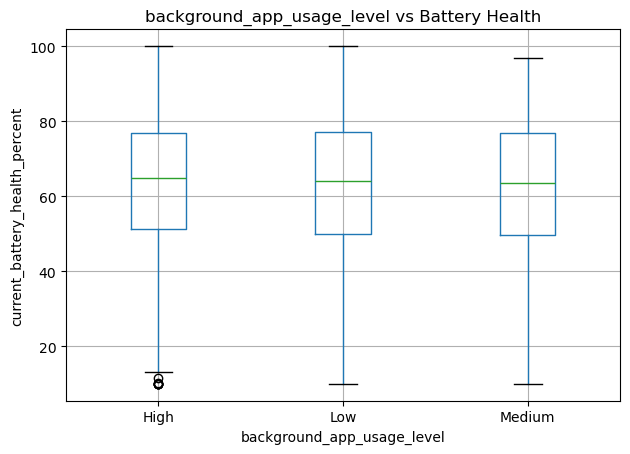


signal_strength_avg — mean battery health by group:
signal_strength_avg
Good        62.681785
Moderate    62.568456
Poor        62.124034
Name: current_battery_health_percent, dtype: float64


<Figure size 600x400 with 0 Axes>

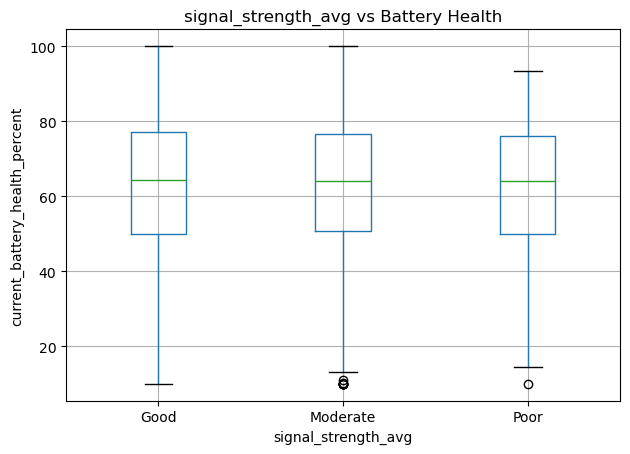

In [35]:
for col in category_columns:
    plt.figure(figsize=(6, 4))
    data.boxplot(column=target, by=col)

    group_means = data.groupby(col)[target].mean()
    print(f"\n{col} — mean battery health by group:")
    print(group_means)

    plt.title(f"{col} vs Battery Health")
    plt.suptitle("")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.tight_layout()
    plt.show()

In [47]:
print("background app usage level has little to no correlation with the battery health ")
print("not worth keeping it as a parameter maybe")
print("same goes for signal strength")

background app usage level has little to no correlation with the battery health 
not worth keeping it as a parameter maybe
same goes for signal strength


In [48]:
order_map_app = {"Low": 0, "Medium": 1, "High": 2}
order_map_signal = {"Poor": 0, "Moderate": 1, "Good": 2}

data["app_usage_encoded"] = data["background_app_usage_level"].map(order_map_app)
data["signal_encoded"] = data["signal_strength_avg"].map(order_map_signal)

all_variables = [
    "device_age_months",
    "battery_capacity_mah",
    "avg_charging_cycles_per_week",
    "fast_charging_usage_percent",
    "overnight_charging_freq_per_week",
    "video_streaming_hours_per_week",
    "gaming_hours_per_week",
    "avg_screen_on_hours_per_day",
    "app_usage_encoded",
    "signal_encoded",
]

corr_matrix = data[all_variables].corr()
print(corr_matrix.loc[["app_usage_encoded", "signal_encoded"]].round(2))

                   device_age_months  battery_capacity_mah  \
app_usage_encoded              -0.01                 -0.01   
signal_encoded                 -0.00                 -0.01   

                   avg_charging_cycles_per_week  fast_charging_usage_percent  \
app_usage_encoded                         -0.01                        -0.00   
signal_encoded                            -0.01                         0.01   

                   overnight_charging_freq_per_week  \
app_usage_encoded                             -0.03   
signal_encoded                                -0.01   

                   video_streaming_hours_per_week  gaming_hours_per_week  \
app_usage_encoded                            0.01                    0.0   
signal_encoded                              -0.00                   -0.0   

                   avg_screen_on_hours_per_day  app_usage_encoded  \
app_usage_encoded                        -0.01               1.00   
signal_encoded                         

In [45]:
print("little to no correlation with other variables also, thus drop the parameters?")

little to no correlation with other variables also, thus drop the parameters?
